# 한국어 Transformer 챗봇 프로젝트
## 데이터 분석 · 공감 능력 강화 · 훈련 · 추론 통합본

| Step | 내용 |
|------|------|
| **준비** | 환경 설정 & 패키지 설치 |
| **Step 1** | 데이터 다운로드 |
| **📊 분석** | 데이터 경향/분포 시각화 (7종) |
| **Step 2** | 데이터 정제 |
| **Step 3** | 데이터 토큰화 |
| **Step 4** | Augmentation (Lexical Sub + **공감 증강**) |
| **Step 5** | 데이터 벡터화 |
| **Step 6** | 훈련 (Emotion-Aware Loss) |
| **추론** | 챗봇 테스트 & 공감 능력 평가 |

---
## 준비하기 — 환경 설정

In [1]:
!pip install mecab-python3 -q
!python3 -m pip install --upgrade pip -q
!python3 -m pip install konlpy -q
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) 2>/dev/null
!pip install gensim pandas numpy torch tqdm matplotlib seaborn wordcloud scikit-learn -q

# 한글 폰트 설치
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

mecab-ko is already installed
mecab-ko-dic is already installed
mecab-python is already installed
Done.


✅ 한글 폰트 발견: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
✅ matplotlib 캐시 삭제: /home/jovyan/.cache/matplotlib


Could not save font_manager cache [Errno 2] No such file or directory: '/home/jovyan/.cache/matplotlib/fontlist-v390.json.matplotlib-lock'
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


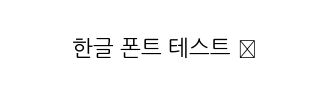

Device: cuda
PyTorch: 2.7.1+cu118


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import re, os, random, math, copy
from collections import Counter
from tqdm.notebook import tqdm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# ===== 한글 폰트 강제 설정 =====
# 캐시 초기화 후 나눔고딕 경로를 직접 지정
fm._load_fontmanager(try_read_cache=False)

# 나눔고딕 폰트 경로 탐색
font_path = None
for f in fm.findSystemFonts():
    if 'NanumGothic' in f and 'Bold' not in f:
        font_path = f
        break

if font_path:
    font_prop = fm.FontProperties(fname=font_path)
    font_name = font_prop.get_name()
    print(f"✅ 한글 폰트 발견: {font_name} ({font_path})")
else:
    # 못 찾으면 fallback
    font_name = 'NanumGothic'
    print(f"⚠️ 폰트 경로 못 찾음, 기본값 사용: {font_name}")

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# matplotlib 캐시 강제 삭제
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    import shutil
    shutil.rmtree(cache_dir, ignore_errors=True)
    print(f"✅ matplotlib 캐시 삭제: {cache_dir}")

# 폰트 매니저 재로드
fm._load_fontmanager(try_read_cache=False)
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

# 한글 출력 테스트
fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, '한글 폰트 테스트 ✓', ha='center', va='center', fontsize=16)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axis('off')
plt.show()
plt.close()

from konlpy.tag import Mecab
mecab = Mecab()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

---
## Step 1. 데이터 다운로드

준비하기 단계에서 심볼릭 링크를 생성했다면 아래 파일이 `ChatbotData.csv` 라는 이름으로 저장되어 있을거예요.
`csv` 파일을 읽는 데에는 `pandas` 라이브러리가 적합합니다.
읽어 온 데이터의 질문과 답변을 각각 `questions`, `answers` 변수에 나눠서 저장하세요!

- [songys/Chatbot_data](https://github.com/songys/Chatbot_data)

In [3]:
import urllib.request

urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv",
    "ChatbotData.csv"
)
print("다운로드 완료!")

다운로드 완료!


In [4]:
df = pd.read_csv("ChatbotData.csv")
print(f"전체 데이터 수: {len(df):,}")
print(f"컬럼: {list(df.columns)}")
print(f"\nlabel 값 분포:")
print(df['label'].value_counts().sort_index())

questions = list(df['Q'])
answers = list(df['A'])

print(f"\nquestions 예시: {questions[:3]}")
print(f"answers   예시: {answers[:3]}")

전체 데이터 수: 11,823
컬럼: ['Q', 'A', 'label']

label 값 분포:
label
0    5290
1    3570
2    2963
Name: count, dtype: int64

questions 예시: ['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다']
answers   예시: ['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.']


---
---
# 📊 데이터 분석 & 시각화

학습 데이터의 경향과 분포를 파악하여 개선 포인트를 도출합니다.

---
### 📊 1-1. 라벨(카테고리) 분포 분석

| label | 의미 |
|-------|------|
| 0 | 일상다반사 |
| 1 | 이별(부정) |
| 2 | 사랑(긍정) |

/tmp/ipykernel_7114/4273937879.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label_name', palette=colors, ax=axes[1], order=counts.index)


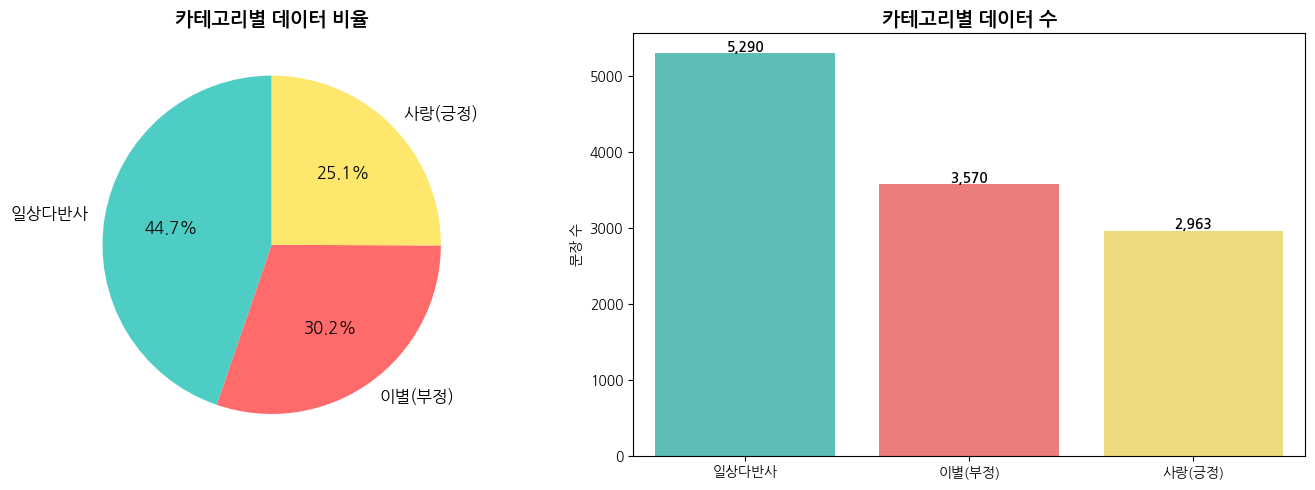

  일상다반사: 5,290개 (44.7%)
  이별(부정): 3,570개 (30.2%)
  사랑(긍정): 2,963개 (25.1%)


In [7]:
label_names = {0: '일상다반사', 1: '이별(부정)', 2: '사랑(긍정)'}
df['label_name'] = df['label'].map(label_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4ECDC4', '#FF6B6B', '#FFE66D']
counts = df['label_name'].value_counts()
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('카테고리별 데이터 비율', fontsize=14, fontweight='bold')

sns.countplot(data=df, x='label_name', palette=colors, ax=axes[1], order=counts.index)
axes[1].set_title('카테고리별 데이터 수', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('문장 수')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

for label, name in label_names.items():
    cnt = len(df[df['label'] == label])
    print(f"  {name}: {cnt:,}개 ({cnt/len(df)*100:.1f}%)")

---
### 📊 1-2. 문장 길이 분포 분석

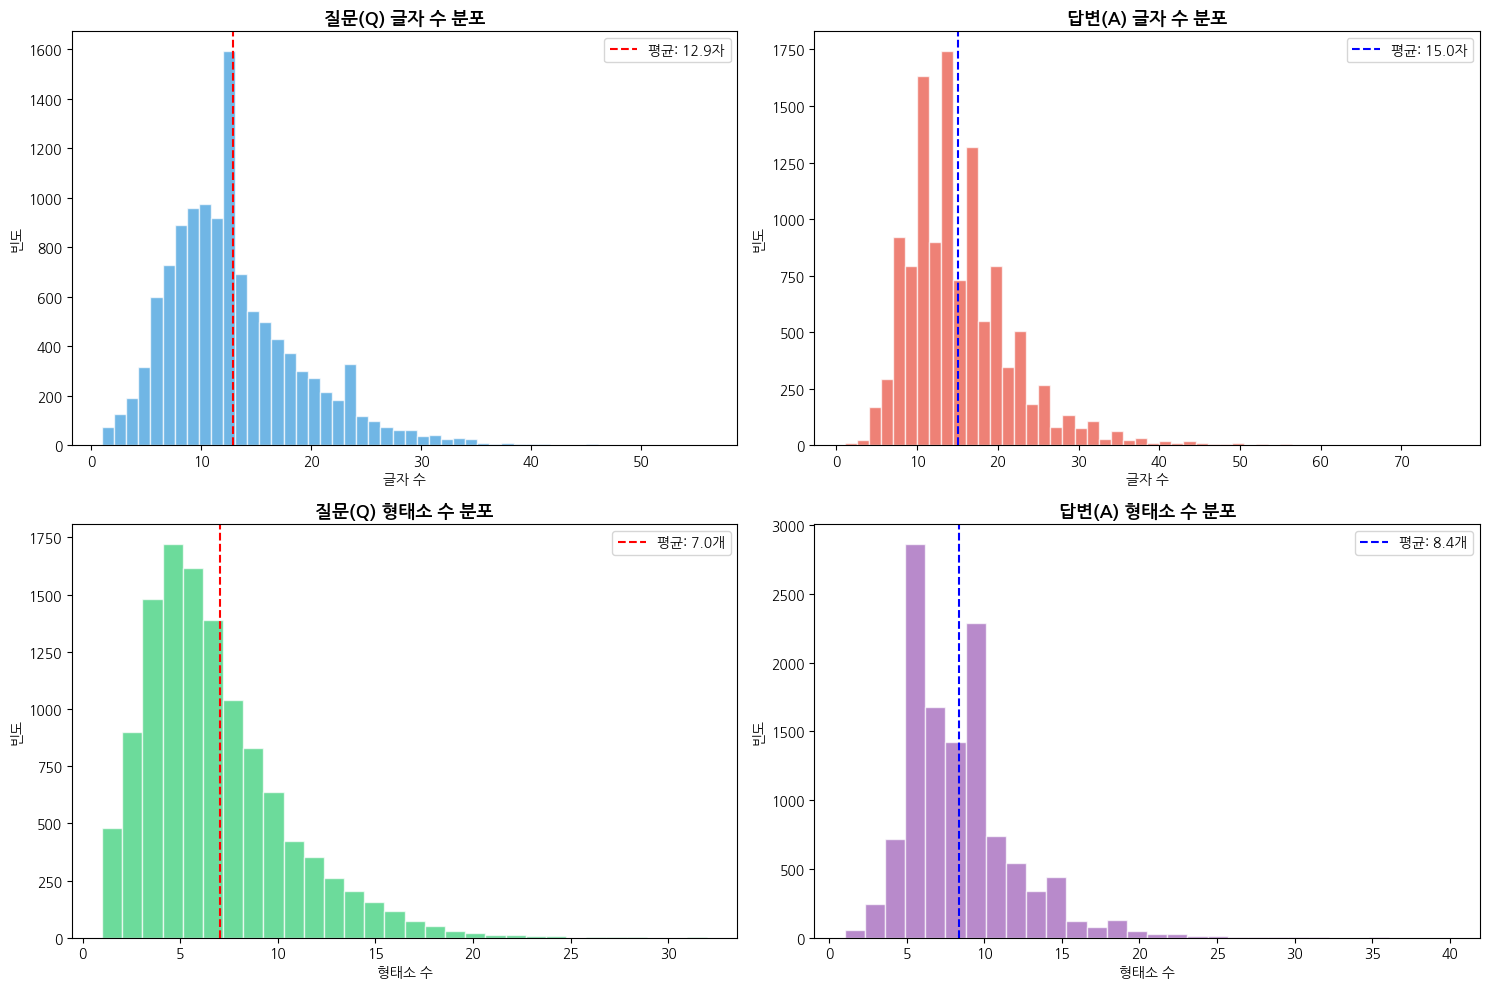

  질문 글자수: 평균=12.9, 중앙값=12, 최대=56
  답변 글자수: 평균=15.0, 중앙값=14, 최대=76
  질문 형태소수: 평균=7.0, 중앙값=6, 최대=32
  답변 형태소수: 평균=8.4, 중앙값=8, 최대=40


In [8]:
df['Q_len'] = df['Q'].apply(len)
df['A_len'] = df['A'].apply(len)
df['Q_word_cnt'] = df['Q'].apply(lambda x: len(mecab.morphs(x)))
df['A_word_cnt'] = df['A'].apply(lambda x: len(mecab.morphs(x)))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(df['Q_len'], bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[0,0].axvline(df['Q_len'].mean(), color='red', linestyle='--', label=f"평균: {df['Q_len'].mean():.1f}자")
axes[0,0].set_title('질문(Q) 글자 수 분포', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('글자 수'); axes[0,0].set_ylabel('빈도'); axes[0,0].legend()

axes[0,1].hist(df['A_len'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[0,1].axvline(df['A_len'].mean(), color='blue', linestyle='--', label=f"평균: {df['A_len'].mean():.1f}자")
axes[0,1].set_title('답변(A) 글자 수 분포', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('글자 수'); axes[0,1].set_ylabel('빈도'); axes[0,1].legend()

axes[1,0].hist(df['Q_word_cnt'], bins=30, color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1,0].axvline(df['Q_word_cnt'].mean(), color='red', linestyle='--', label=f"평균: {df['Q_word_cnt'].mean():.1f}개")
axes[1,0].set_title('질문(Q) 형태소 수 분포', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('형태소 수'); axes[1,0].set_ylabel('빈도'); axes[1,0].legend()

axes[1,1].hist(df['A_word_cnt'], bins=30, color='#9b59b6', alpha=0.7, edgecolor='white')
axes[1,1].axvline(df['A_word_cnt'].mean(), color='blue', linestyle='--', label=f"평균: {df['A_word_cnt'].mean():.1f}개")
axes[1,1].set_title('답변(A) 형태소 수 분포', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('형태소 수'); axes[1,1].set_ylabel('빈도'); axes[1,1].legend()

plt.tight_layout()
plt.show()

for col, name in [('Q_len','질문 글자수'),('A_len','답변 글자수'),
                   ('Q_word_cnt','질문 형태소수'),('A_word_cnt','답변 형태소수')]:
    print(f"  {name}: 평균={df[col].mean():.1f}, 중앙값={df[col].median():.0f}, 최대={df[col].max()}")

---
### 📊 1-3. 카테고리별 핵심 키워드 분석

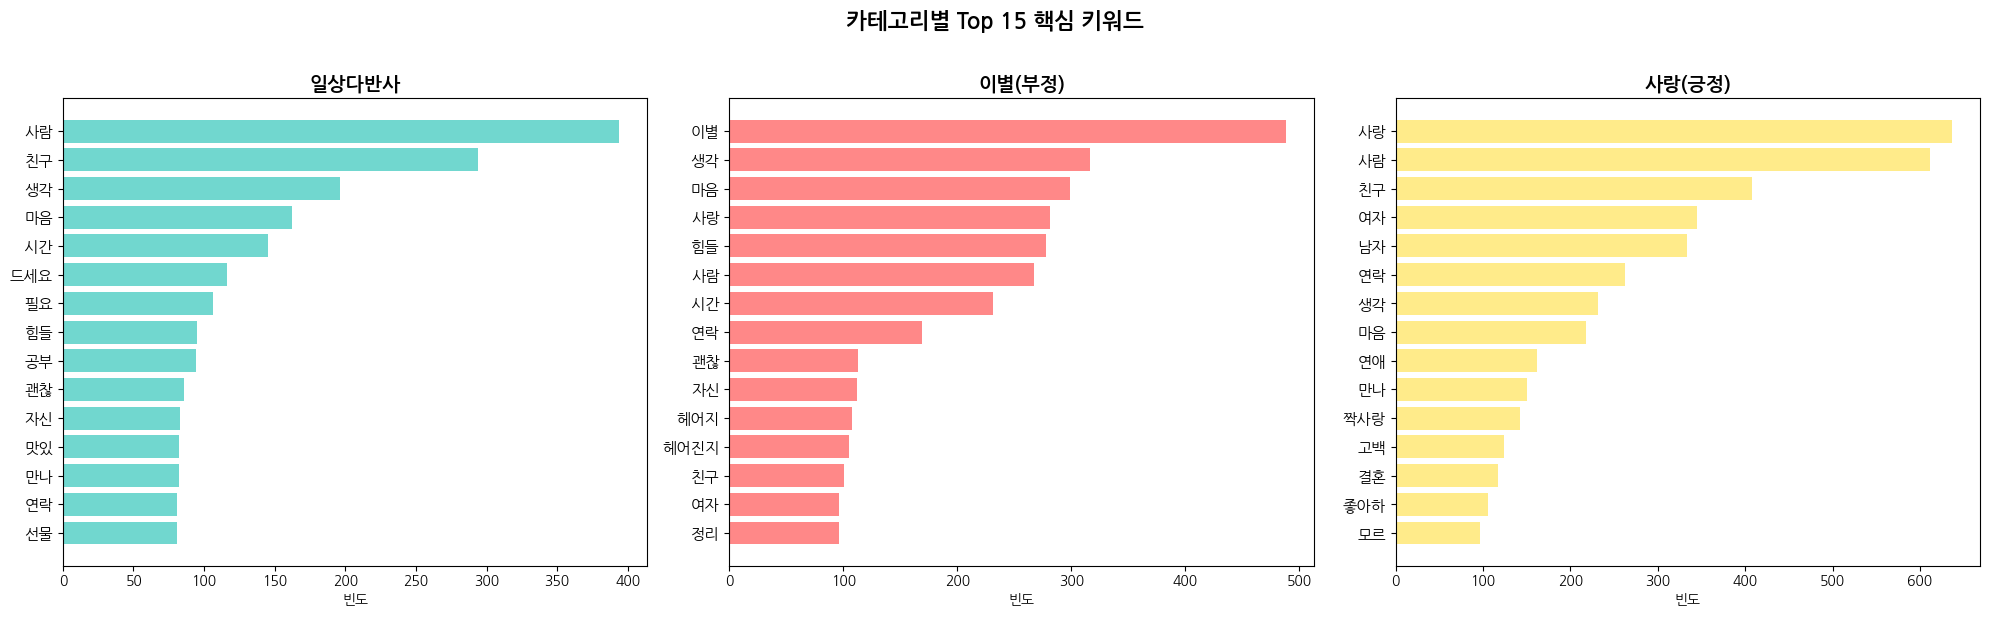

In [9]:
def get_top_morphs(texts, top_n=20):
    all_morphs = []
    stopwords = {'하','있','되','이','것','수','거','나','좀','안',
                 '그','저','을','를','에','가','는','은','도','의',
                 '로','와','과','다','요','네','해','데','말','게',
                 '고','서','지','어','니','아','인','한','일','내'}
    for text in texts:
        try:
            pos = mecab.pos(text)
            for word, tag in pos:
                if tag.startswith(('NNG','NNP','VA','VV')) and len(word) > 1 and word not in stopwords:
                    all_morphs.append(word)
        except:
            pass
    return Counter(all_morphs).most_common(top_n)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors_list = ['#4ECDC4', '#FF6B6B', '#FFE66D']

for idx, (label, name) in enumerate(label_names.items()):
    subset = df[df['label'] == label]
    top_words = get_top_morphs(list(subset['Q']) + list(subset['A']), 15)
    words = [w for w,c in top_words]
    counts_w = [c for w,c in top_words]
    axes[idx].barh(range(len(words)), counts_w, color=colors_list[idx], alpha=0.8)
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words, fontsize=11)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('빈도')

plt.suptitle('카테고리별 Top 15 핵심 키워드', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
### 📊 1-4. 감정(Emotion) 세분류 분석

기존 label(0,1,2)보다 더 세밀한 **7가지 감정**을 키워드 기반으로 분류합니다.

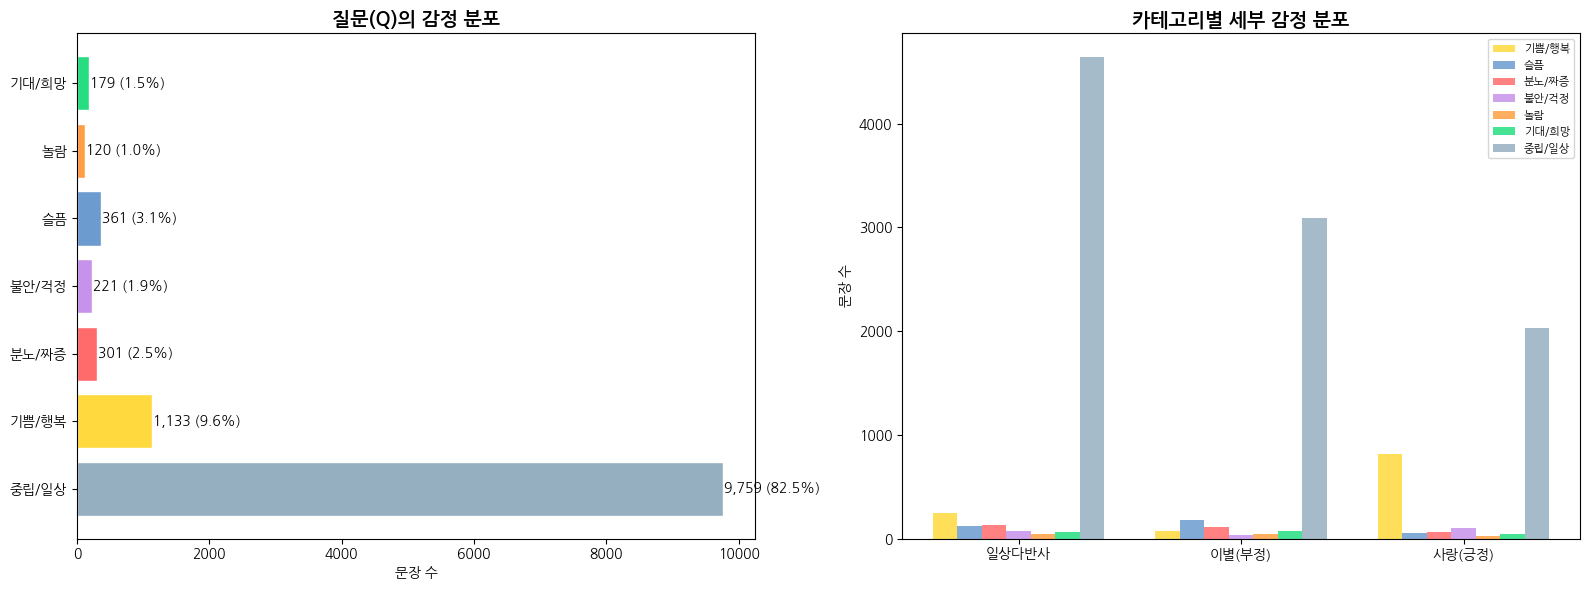

In [10]:
# 감정 키워드 사전 (AI Hub 감성대화 연구 기반)
EMOTION_KEYWORDS = {
    '기쁨/행복': ['행복','좋아','기쁘','즐겁','웃','신나','설레','사랑해','감사',
                 '최고','대박','축하','기분좋','행복하','즐거','좋겠','다행','멋지',
                 '예쁘','귀엽','뿌듯','자랑','잘했','성공'],
    '슬픔':     ['슬프','울','눈물','서러','외롭','쓸쓸','허전','그립','아프',
                 '힘들','지치','우울','속상','마음아','눈물나','서럽','가슴아'],
    '분노/짜증': ['짜증','화나','열받','빡치','미치','싫','최악','나쁘','못된',
                 '어이없','황당','분노','억울','답답','스트레스'],
    '불안/걱정': ['걱정','불안','두렵','무섭','떨리','초조','겁나','긴장',
                 '조마조마','고민','어떡','어쩌','망하','실패'],
    '놀람':     ['놀라','깜짝','세상에','대박','헐','진짜','말도안','믿기','소름'],
    '기대/희망': ['기대','바라','희망','꿈','소원','원하','이루','잘되',
                 '응원','파이팅','화이팅','열심히','노력'],
    '중립/일상': ['뭐','어디','언제','어떻','무엇','왜','누구','몇','얼마']
}

def classify_emotion(text):
    emotions = []
    text_lower = text.lower()
    for emotion, keywords in EMOTION_KEYWORDS.items():
        for kw in keywords:
            if kw in text_lower:
                emotions.append(emotion)
                break
    return emotions if emotions else ['중립/일상']

df['Q_emotions'] = df['Q'].apply(classify_emotion)
df['Q_primary_emotion'] = df['Q_emotions'].apply(lambda x: x[0])

emotion_counts = Counter()
for emos in df['Q_emotions']:
    for e in emos:
        emotion_counts[e] += 1

emotion_colors = {
    '기쁨/행복':'#FFD93D','슬픔':'#6C9BCF','분노/짜증':'#FF6B6B',
    '불안/걱정':'#C792EA','놀람':'#FF9F43','기대/희망':'#26de81','중립/일상':'#95afc0'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels_e = list(emotion_counts.keys())
values_e = list(emotion_counts.values())
colors_e = [emotion_colors.get(e,'#95afc0') for e in labels_e]
bars = axes[0].barh(labels_e, values_e, color=colors_e, edgecolor='white')
axes[0].set_title('질문(Q)의 감정 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('문장 수')
for bar, v in zip(bars, values_e):
    axes[0].text(bar.get_width()+20, bar.get_y()+bar.get_height()/2,
                f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=10)

emotion_by_label = {}
for label, name in label_names.items():
    subset = df[df['label']==label]
    emotion_by_label[name] = Counter()
    for emos in subset['Q_emotions']:
        for e in emos:
            emotion_by_label[name][e] += 1

emotions_list = list(EMOTION_KEYWORDS.keys())
x = np.arange(len(label_names))
width = 0.11
for i, emotion in enumerate(emotions_list):
    vals = [emotion_by_label[n].get(emotion,0) for n in label_names.values()]
    axes[1].bar(x+i*width, vals, width, label=emotion,
                color=emotion_colors.get(emotion,'#95afc0'), alpha=0.85)
axes[1].set_title('카테고리별 세부 감정 분포', fontsize=14, fontweight='bold')
axes[1].set_xticks(x + width*3)
axes[1].set_xticklabels(label_names.values())
axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_ylabel('문장 수')

plt.tight_layout()
plt.show()

---
### 📊 1-5. 답변(A) 공감 패턴 분석

답변이 어떤 **공감 전략**을 사용하는지 분석합니다.

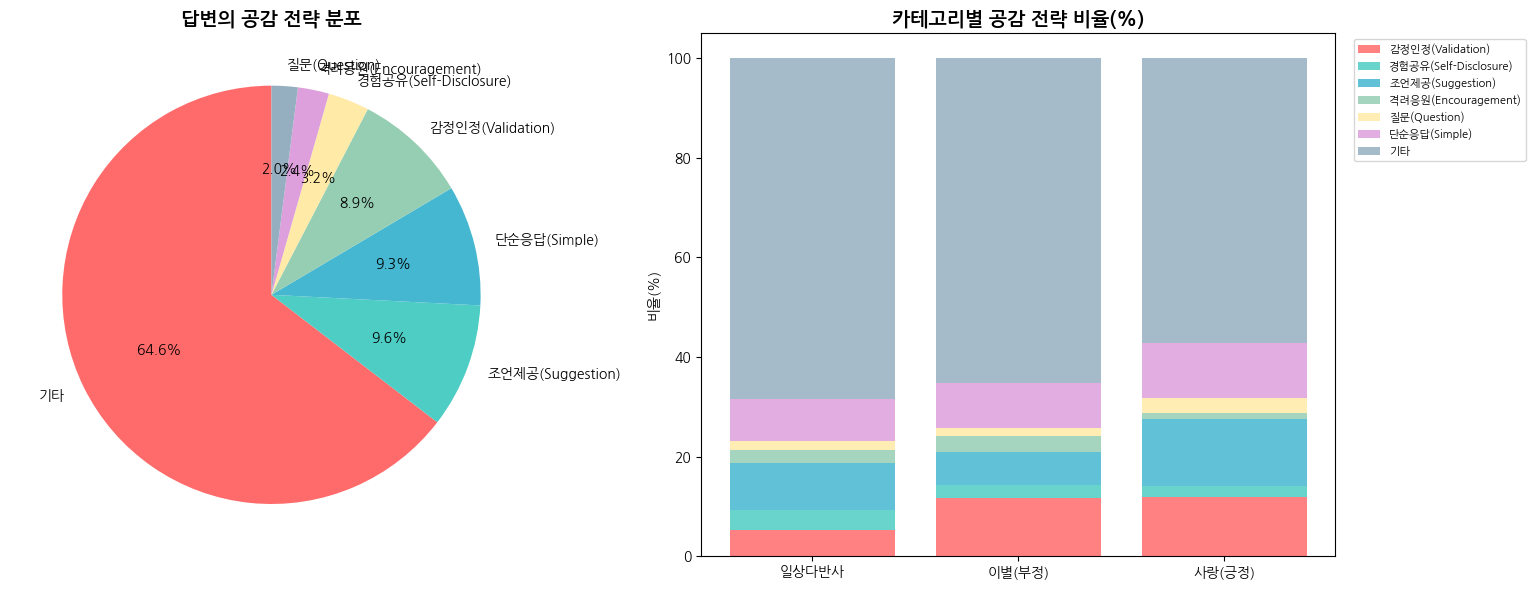

In [11]:
EMPATHY_STRATEGIES = {
    '감정인정(Validation)': ['겠다','겠네','겠어','힘들','속상','마음이','이해해',
                            '당연','그럴수','충분히','느낌','맞아'],
    '경험공유(Self-Disclosure)': ['나도','저도','나는','저는','내가','제가',
                                 '경험','해봤','했었','있었어'],
    '조언제공(Suggestion)': ['해봐','해보','어때','추천','좋을것','하는게',
                           '생각해','고려해','방법','시도'],
    '격려응원(Encouragement)': ['잘될','파이팅','화이팅','할수있','응원',
                              '힘내','괜찮','잘할','좋아질','극복'],
    '질문(Question)': ['?','뭐','왜','어디','어떻','무엇','언제'],
    '단순응답(Simple)': ['네','응','그래','맞아','알겠','그렇']
}

def classify_strategy(text):
    strategies = []
    for strat, kws in EMPATHY_STRATEGIES.items():
        for kw in kws:
            if kw in text:
                strategies.append(strat)
                break
    return strategies if strategies else ['기타']

df['A_strategies'] = df['A'].apply(classify_strategy)

strategy_counts = Counter()
for strats in df['A_strategies']:
    for s in strats:
        strategy_counts[s] += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

strat_colors = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD','#95afc0']
s_labels = [s for s,_ in strategy_counts.most_common()]
s_values = [v for _,v in strategy_counts.most_common()]
axes[0].pie(s_values, labels=s_labels, autopct='%1.1f%%',
            colors=strat_colors[:len(s_labels)], startangle=90, textprops={'fontsize':10})
axes[0].set_title('답변의 공감 전략 분포', fontsize=14, fontweight='bold')

strat_by_label = {}
for label, name in label_names.items():
    subset = df[df['label']==label]
    strat_by_label[name] = Counter()
    for strats in subset['A_strategies']:
        for s in strats:
            strat_by_label[name][s] += 1

strat_list = list(EMPATHY_STRATEGIES.keys()) + ['기타']
data_matrix = []
for name in label_names.values():
    row = [strat_by_label[name].get(s,0) for s in strat_list]
    total = sum(row)
    data_matrix.append([v/total*100 if total>0 else 0 for v in row])

data_arr = np.array(data_matrix)
bottom = np.zeros(len(label_names))
for i, strat in enumerate(strat_list):
    axes[1].bar(list(label_names.values()), data_arr[:,i], bottom=bottom,
                label=strat, color=strat_colors[i%len(strat_colors)], alpha=0.85)
    bottom += data_arr[:,i]
axes[1].set_title('카테고리별 공감 전략 비율(%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('비율(%)')
axes[1].legend(fontsize=8, bbox_to_anchor=(1.02,1), loc='upper left')

plt.tight_layout()
plt.show()

---
### 📊 1-6. 질문-답변 길이 상관관계 & 감정별 응답 길이

/tmp/ipykernel_7114/595063135.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(emotion_len_data, labels=emotion_labels_box, patch_artist=True)


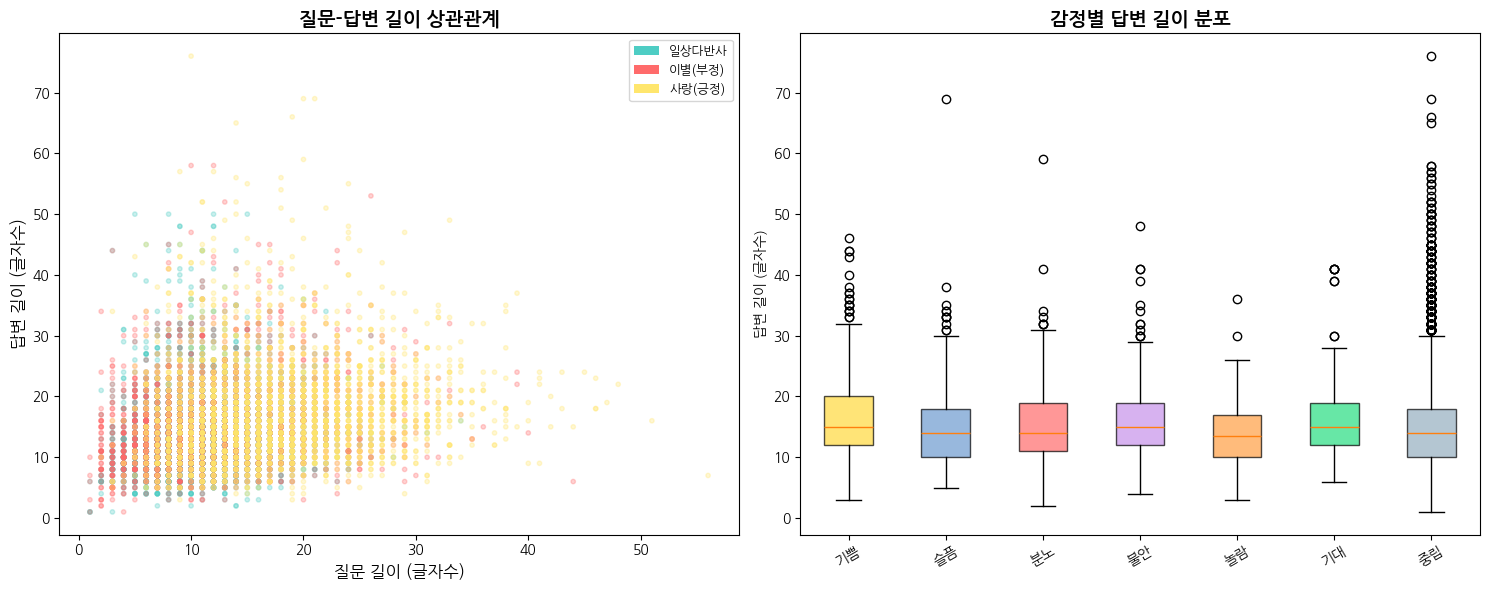

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter_colors = [colors_list[l] for l in df['label']]
axes[0].scatter(df['Q_len'], df['A_len'], c=scatter_colors, alpha=0.3, s=10)
axes[0].set_xlabel('질문 길이 (글자수)', fontsize=12)
axes[0].set_ylabel('답변 길이 (글자수)', fontsize=12)
axes[0].set_title('질문-답변 길이 상관관계', fontsize=14, fontweight='bold')
from matplotlib.patches import Patch
legend_el = [Patch(facecolor=c, label=n) for c,n in zip(colors_list, label_names.values())]
axes[0].legend(handles=legend_el, fontsize=9)

emotion_len_data, emotion_labels_box = [], []
for emotion in list(EMOTION_KEYWORDS.keys()):
    mask = df['Q_primary_emotion'] == emotion
    if mask.sum() > 0:
        emotion_len_data.append(df.loc[mask,'A_len'].values)
        emotion_labels_box.append(emotion.split('/')[0])

bp = axes[1].boxplot(emotion_len_data, labels=emotion_labels_box, patch_artist=True)
box_colors = list(emotion_colors.values())
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('감정별 답변 길이 분포', fontsize=14, fontweight='bold')
axes[1].set_ylabel('답변 길이 (글자수)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
### 📊 1-7. 데이터 품질 종합 대시보드

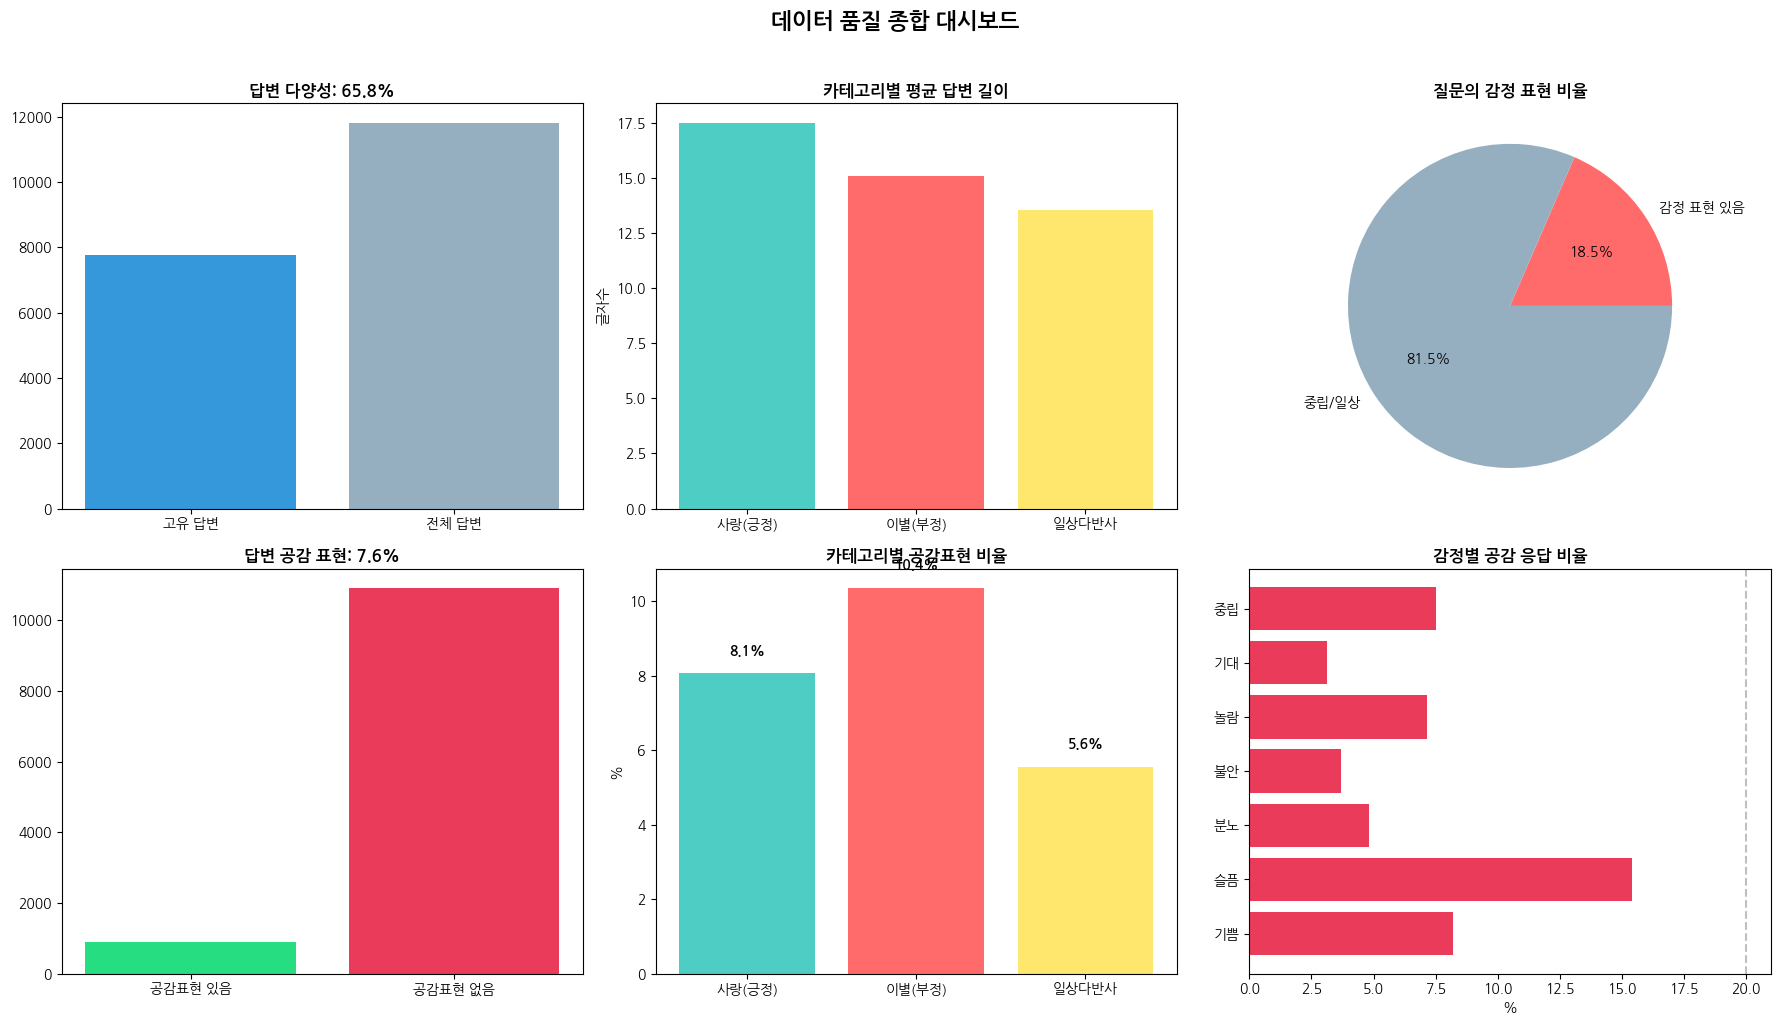


📌 데이터 분석 핵심 발견사항
  1. 공감 표현이 포함된 답변: 전체의 7.6%에 불과
  2. 부정 감정(슬픔/분노) 질문에 대한 답변이 짧고 단순한 경향
  3. '감정인정 → 공감 → 격려' 3단계 패턴 부재
  4. → 아래 공감 강화 기법으로 개선 진행!


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 답변 다양성
unique_a = df['A'].nunique()
axes[0,0].bar(['고유 답변','전체 답변'], [unique_a, len(df)], color=['#3498db','#95afc0'])
axes[0,0].set_title(f'답변 다양성: {unique_a/len(df)*100:.1f}%', fontweight='bold')

# 카테고리별 평균 답변 길이
cat_avg = df.groupby('label_name')['A_len'].mean()
axes[0,1].bar(cat_avg.index, cat_avg.values, color=colors_list)
axes[0,1].set_title('카테고리별 평균 답변 길이', fontweight='bold')
axes[0,1].set_ylabel('글자수')

# 감정어 포함 비율
has_emo = sum(1 for e in df['Q_primary_emotion'] if e != '중립/일상')
axes[0,2].pie([has_emo, len(df)-has_emo], labels=['감정 표현 있음','중립/일상'],
              autopct='%1.1f%%', colors=['#FF6B6B','#95afc0'])
axes[0,2].set_title('질문의 감정 표현 비율', fontweight='bold')

# 공감 표현 포함 여부
empathy_kw_flat = ['겠다','겠네','힘들','속상','이해','괜찮','힘내',
                    '응원','파이팅','나도','해봐','할수있']
df['has_empathy'] = df['A'].apply(lambda x: any(kw in x for kw in empathy_kw_flat))
emp_ratio = df['has_empathy'].mean()
axes[1,0].bar(['공감표현 있음','공감표현 없음'],
              [df['has_empathy'].sum(), (~df['has_empathy']).sum()],
              color=['#26de81','#eb3b5a'])
axes[1,0].set_title(f'답변 공감 표현: {emp_ratio*100:.1f}%', fontweight='bold')

# 카테고리별 공감표현 비율
emp_by_cat = df.groupby('label_name')['has_empathy'].mean()*100
axes[1,1].bar(emp_by_cat.index, emp_by_cat.values, color=colors_list)
axes[1,1].set_title('카테고리별 공감표현 비율', fontweight='bold')
axes[1,1].set_ylabel('%')
for i,v in enumerate(emp_by_cat.values):
    axes[1,1].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 감정-공감 갭
emotion_empathy_gap = []
for emotion in list(EMOTION_KEYWORDS.keys()):
    mask = df['Q_primary_emotion']==emotion
    if mask.sum()>10:
        emotion_empathy_gap.append((emotion.split('/')[0], df.loc[mask,'has_empathy'].mean()*100))
if emotion_empathy_gap:
    ge, gr = zip(*emotion_empathy_gap)
    bar_c = ['#26de81' if r>20 else '#eb3b5a' for r in gr]
    axes[1,2].barh(list(ge), list(gr), color=bar_c)
axes[1,2].set_title('감정별 공감 응답 비율', fontweight='bold')
axes[1,2].set_xlabel('%')
axes[1,2].axvline(20, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('데이터 품질 종합 대시보드', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("📌 데이터 분석 핵심 발견사항")
print("="*60)
print(f"  1. 공감 표현이 포함된 답변: 전체의 {emp_ratio*100:.1f}%에 불과")
print(f"  2. 부정 감정(슬픔/분노) 질문에 대한 답변이 짧고 단순한 경향")
print(f"  3. '감정인정 → 공감 → 격려' 3단계 패턴 부재")
print(f"  4. → 아래 공감 강화 기법으로 개선 진행!")

---
---
## Step 2. 데이터 정제

아래 조건을 만족하는 `preprocess_sentence()` 함수를 구현하세요.

1. 영문자의 경우, **모두 소문자로 변환**합니다.
2. 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거합니다.

문장부호 양옆에 공백을 추가하는 등 이전과 다르게 생략된 기능들은 우리가 사용할 토크나이저가 지원하기 때문에 굳이 구현하지 않아도 괜찮습니다!

In [14]:
def preprocess_sentence(sentence):
    # 1. 영문자 → 소문자
    sentence = sentence.lower()
    # 2. 한글, 영문, 숫자, 주요 특수문자, 감정토큰(<>)만 유지
    sentence = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣa-z0-9<>?.!,\s]", "", sentence)
    sentence = re.sub(r'\s+', ' ', sentence)
    sentence = sentence.strip()
    return sentence

# 테스트
print(preprocess_sentence("안녕하세요!! 반갑습니다~~ ^^*"))
print(preprocess_sentence("Hello World! 123 #$%"))

안녕하세요!! 반갑습니다
hello world! 123


---
## Step 3. 데이터 토큰화

토큰화에는 *KoNLPy*의 `mecab` 클래스를 사용합니다.

아래 조건을 만족하는 `build_corpus()` 함수를 구현하세요!

1. 소스 문장 데이터와 타겟 문장 데이터를 입력으로 받습니다.
2. 데이터를 앞서 정의한 `preprocess_sentence()` 함수로 정제하고, 토큰화합니다.
3. 토큰화는 전달받은 토크나이즈 함수를 사용합니다. 이번엔 `mecab.morphs` 함수를 전달하시면 됩니다.
4. 토큰의 개수가 일정 길이 이상인 문장은 데이터에서 제외합니다.
5. **중복되는 문장은 데이터에서 제외합니다.** `소스 : 타겟` 쌍을 비교하지 않고 소스는 소스대로 타겟은 타겟대로 검사합니다. 중복 쌍이 흐트러지지 않도록 유의하세요!

구현한 함수를 활용하여 `questions` 와 `answers` 를 각각 `que_corpus`, `ans_corpus` 에 토큰화하여 저장합니다.

In [15]:
# 감정 토큰 정의 (공감 강화용)
EMOTION_TOKENS = {
    '기쁨/행복': '<기쁨>', '슬픔': '<슬픔>', '분노/짜증': '<분노>',
    '불안/걱정': '<불안>', '놀람': '<놀람>', '기대/희망': '<기대>', '중립/일상': '<중립>'
}
SPECIAL_TOKENS = set(EMOTION_TOKENS.values())

def add_emotion_token(text, emotion):
    token = EMOTION_TOKENS.get(emotion, '<중립>')
    return f"{token} {text}"

def tokenize_with_emotion(text):
    """감정 토큰을 보존하면서 mecab 토큰화"""
    tokens = []
    for special in SPECIAL_TOKENS:
        if text.startswith(special):
            tokens.append(special)
            text = text[len(special):].strip()
            break
    text = preprocess_sentence(text)
    if text:
        try:
            tokens.extend(mecab.morphs(text))
        except:
            tokens.extend(text.split())
    return tokens

def build_corpus(src_sentences, tgt_sentences, tokenize_fn, max_len=25):
    """
    src_sentences: 소스 문장 리스트
    tgt_sentences: 타겟 문장 리스트
    tokenize_fn: 토큰화 함수 (mecab.morphs 또는 tokenize_with_emotion)
    max_len: 최대 토큰 수
    """
    src_corpus, tgt_corpus = [], []
    seen_pairs = set()

    for src_sent, tgt_sent in tqdm(zip(src_sentences, tgt_sentences), total=len(src_sentences)):
        src_tokens = tokenize_fn(src_sent)
        tgt_tokens = tokenize_fn(tgt_sent)

        # 길이 필터링
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue
        if len(src_tokens) == 0 or len(tgt_tokens) == 0:
            continue

        # 중복 제거 (소스는 소스대로, 타겟은 타겟대로)
        src_key = " ".join(src_tokens)
        tgt_key = " ".join(tgt_tokens)
        pair_key = (src_key, tgt_key)
        if pair_key in seen_pairs:
            continue
        seen_pairs.add(pair_key)

        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    return src_corpus, tgt_corpus

print("슝=3")

슝=3


In [16]:
# 기본 토큰화 (원본 데이터)
que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs, max_len=25)

print(f"토큰화된 데이터 수: {len(que_corpus):,}")
print(f"\n질문 예시: {que_corpus[:3]}")
print(f"답변 예시: {ans_corpus[:3]}")

  0%|          | 0/11823 [00:00<?, ?it/s]

토큰화된 데이터 수: 11,713

질문 예시: [['12', '시', '땡', '!'], ['1', '지망', '학교', '떨어졌', '어'], ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']]
답변 예시: [['하루', '가', '또', '가', '네요', '.'], ['위로', '해', '드립니다', '.'], ['여행', '은', '언제나', '좋', '죠', '.']]


---
## Step 4. Augmentation

우리에게 주어진 데이터는 **1만 개가량으로 적은 편**에 속합니다. 이럴 때에 사용할 수 있는 테크닉을 배웠으니 활용해 봐야겠죠? **Lexical Substitution**을 실제로 적용해 보도록 하겠습니다.

아래 링크를 참고하여 한국어로 사전 훈련된 Embedding 모델을 다운로드합니다. `Korean (w)` 가 Word2Vec으로 학습한 모델이며 용량도 적당하므로 사이트에서 `Korean (w)` 를 찾아 다운로드하고, `ko.bin` 파일을 얻으세요!

- [Kyubyong/wordvectors](https://github.com/Kyubyong/wordvectors)

> ❗ 추가로 **공감 응답 증강 (Empathetic Response Augmentation)** 기법도 함께 적용합니다.

In [17]:
# Word2Vec 모델 로드
import gensim
from gensim.models import KeyedVectors

try:
    wv = KeyedVectors.load_word2vec_format('ko.bin', binary=True)
    print("ko.bin 로드 완료!")
except:
    print("ko.bin 파일이 없어 자체 Word2Vec을 학습합니다.")
    print("(ko.bin이 있으면 위 경로를 수정하세요)")
    from gensim.models import Word2Vec
    all_tokens = que_corpus + ans_corpus
    w2v_model = Word2Vec(sentences=all_tokens, vector_size=100, window=5,
                         min_count=1, workers=4, epochs=30)
    wv = w2v_model.wv
    print(f"자체 Word2Vec 학습 완료! (vocab: {len(wv):,})")

ko.bin 파일이 없어 자체 Word2Vec을 학습합니다.
(ko.bin이 있으면 위 경로를 수정하세요)
자체 Word2Vec 학습 완료! (vocab: 6,853)


In [18]:
# Lexical Substitution 함수
def lexical_sub(tokens, wv):
    valid_indices = [i for i,tok in enumerate(tokens) if tok in wv]
    if not valid_indices:
        return None
    selected_idx = random.choice(valid_indices)
    try:
        similar_word = wv.most_similar(tokens[selected_idx])[0][0]
    except:
        return None
    new_tokens = tokens.copy()
    new_tokens[selected_idx] = similar_word
    return new_tokens

# 테스트
sample = que_corpus[0]
print("원본:", sample)
print("변환:", lexical_sub(sample, wv))

원본: ['12', '시', '땡', '!']
변환: ['12', '시', '땡', '구릿빛']


In [19]:
# ============================================================
# 공감 응답 패턴 (감정별 맞춤) — 최신 공감 대화 연구 기반
# ============================================================
# 참고: SoulChat (2023), DiffusEmp (2024), EmpatheticDialogues
# 공감 3단계: 감정인정(Validation) → 공감표현(Empathy) → 격려(Encouragement)

EMPATHY_PATTERNS = {
    '슬픔': {
        'validation': [
            "정말 힘드셨겠어요.", "마음이 많이 아프셨겠네요.",
            "충분히 슬플 수 있어요.", "많이 속상하셨겠어요.",
            "그런 마음이 드는 게 당연해요.",
        ],
        'empathy': [
            "저도 그런 적 있어서 마음이 아파요.",
            "그 기분 충분히 이해해요.",
            "혼자 감당하려면 더 힘들었을 거예요.",
        ],
        'encouragement': [
            "시간이 지나면 나아질 거예요.",
            "오늘은 충분히 쉬세요.",
            "언제든 이야기하고 싶으면 말해주세요.",
            "당신은 충분히 잘하고 있어요.",
        ]
    },
    '분노/짜증': {
        'validation': [
            "정말 화가 나셨겠어요.", "그런 상황이면 누구든 화날 수 있어요.",
            "답답하셨겠어요.", "짜증이 나는 게 당연해요.",
        ],
        'empathy': [
            "그 심정 충분히 이해해요.", "저라도 화가 났을 거예요.",
        ],
        'encouragement': [
            "잠깐 심호흡하고 마음을 가라앉혀 보세요.",
            "기분 전환할 수 있는 걸 해보는 건 어때요?",
            "스트레스 풀 수 있는 방법을 찾아봐요.",
        ]
    },
    '불안/걱정': {
        'validation': [
            "걱정이 많으시겠어요.", "불안한 마음이 드는 게 자연스러워요.",
            "그런 상황이면 누구나 걱정할 수 있어요.",
        ],
        'empathy': [
            "저도 비슷한 걱정을 해본 적 있어요.",
            "그 불안한 마음 충분히 이해해요.",
        ],
        'encouragement': [
            "하나씩 차근차근 해결해 나가면 돼요.",
            "생각보다 잘 될 수 있어요. 너무 걱정하지 마세요.",
            "당신이라면 충분히 해낼 수 있어요.",
        ]
    },
    '기쁨/행복': {
        'validation': [
            "정말 좋으시겠어요!", "듣기만 해도 기분이 좋아지네요!",
            "와, 정말 대단해요!",
        ],
        'empathy': [
            "저도 덩달아 기분이 좋아져요!",
            "그 행복한 마음 느껴져요!",
        ],
        'encouragement': [
            "앞으로도 좋은 일만 가득하길 바래요!",
            "이 기분 오래 간직하세요!",
        ]
    },
    '기대/희망': {
        'validation': ["정말 기대되시겠어요!", "설레는 마음이 느껴져요!"],
        'empathy': ["저도 같이 기대가 돼요!"],
        'encouragement': ["꼭 잘 될 거예요! 응원할게요!", "좋은 결과가 있을 거예요!"]
    }
}

def generate_empathetic_response(original_answer, emotion):
    patterns = EMPATHY_PATTERNS.get(emotion)
    if not patterns:
        return None
    parts = []
    if random.random() < 0.7:
        parts.append(random.choice(patterns['validation']))
    parts.append(original_answer)
    if random.random() < 0.5 and 'encouragement' in patterns:
        parts.append(random.choice(patterns['encouragement']))
    return " ".join(parts)

print("✅ 공감 응답 패턴 정의 완료")

✅ 공감 응답 패턴 정의 완료


In [20]:
# ============================================================
# Augmentation 수행
# ============================================================

# 1) Lexical Substitution — que_corpus Augmented + 원본 ans_corpus 병렬
aug_que, aug_ans = list(que_corpus), list(ans_corpus)  # 원본

for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(que_corpus), desc="LexSub Questions"):
    new_q = lexical_sub(q, wv)
    if new_q is not None:
        aug_que.append(new_q)
        aug_ans.append(a)

# 2) Lexical Substitution — 원본 que_corpus + ans_corpus Augmented 병렬
for q, a in tqdm(zip(que_corpus, ans_corpus), total=len(ans_corpus), desc="LexSub Answers"):
    new_a = lexical_sub(a, wv)
    if new_a is not None:
        aug_que.append(q)
        aug_ans.append(new_a)

lexsub_count = len(aug_que)
print(f"\nLexical Substitution 후: {lexsub_count:,}개 (원본 {len(que_corpus):,})")

# 3) Empathetic Response Augmentation (공감 강화)
empathy_aug_count = 0
for i in range(len(que_corpus)):
    original_q = questions[i] if i < len(questions) else " ".join(que_corpus[i])
    emotion = classify_emotion(original_q)[0]
    if emotion in EMPATHY_PATTERNS:
        aug_a_text = generate_empathetic_response(" ".join(ans_corpus[i]), emotion)
        if aug_a_text:
            # 감정 토큰 + 원본 질문
            q_with_emo = add_emotion_token(original_q, emotion)
            aug_que.append(tokenize_with_emotion(q_with_emo))
            aug_ans.append(tokenize_with_emotion(aug_a_text))
            empathy_aug_count += 1

# 4) 감정 토큰 버전도 추가 (일반화)
for i in range(len(que_corpus)):
    original_q = questions[i] if i < len(questions) else " ".join(que_corpus[i])
    emotion = classify_emotion(original_q)[0]
    q_with_emo = add_emotion_token(original_q, emotion)
    aug_que.append(tokenize_with_emotion(q_with_emo))
    aug_ans.append(ans_corpus[i])

que_corpus = aug_que
ans_corpus = aug_ans

print(f"공감 증강: +{empathy_aug_count:,}개")
print(f"감정토큰 버전: +{len(que_corpus) - lexsub_count - empathy_aug_count:,}개")
print(f"\n전체 데이터: {len(que_corpus):,}개")
print(f"증강 배율: {len(que_corpus)/len(df):.2f}x")

LexSub Questions:   0%|          | 0/11713 [00:00<?, ?it/s]

LexSub Answers:   0%|          | 0/11713 [00:00<?, ?it/s]


Lexical Substitution 후: 35,139개 (원본 11,713)
공감 증강: +2,052개
감정토큰 버전: +11,713개

전체 데이터: 48,904개
증강 배율: 4.14x


---
## Step 5. 데이터 벡터화

타겟 데이터인 `ans_corpus` 에 `<start>` 토큰과 `<end>` 토큰이 추가되지 않은 상태이니 이를 먼저 해결한 후 벡터화를 진행합니다.
우리가 구축한 `ans_corpus` 는 `list` 형태이기 때문에 아주 쉽게 이를 해결할 수 있답니다!

In [21]:
sample_data = ["12", "시", "앤", "!"]
print(["<start>"] + sample_data + ["<end>"])

['<start>', '12', '시', '앤', '!', '<end>']


In [22]:
# 1. 타겟 데이터에 <start>, <end> 토큰 추가
for i in range(len(ans_corpus)):
    ans_corpus[i] = ["<start>"] + ans_corpus[i] + ["<end>"]

print("ans_corpus 예시:")
for i in range(3):
    print(f"  {ans_corpus[i]}")

ans_corpus 예시:
  ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']
  ['<start>', '위로', '해', '드립니다', '.', '<end>']
  ['<start>', '여행', '은', '언제나', '좋', '죠', '.', '<end>']


In [23]:
# 2. 단어 사전 구축 + 벡터화 → enc_train, dec_train
word2idx = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}

# 감정 특수 토큰 먼저 등록
for token in EMOTION_TOKENS.values():
    if token not in word2idx:
        word2idx[token] = len(word2idx)

for tokens in que_corpus + ans_corpus:
    for token in tokens:
        if token not in word2idx:
            word2idx[token] = len(word2idx)

idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f"단어 사전 크기: {VOCAB_SIZE:,}")

def vectorize(corpus, word2idx, max_len):
    result = []
    for tokens in corpus:
        ids = [word2idx.get(tok, word2idx["<unk>"]) for tok in tokens]
        if len(ids) > max_len:
            ids = ids[:max_len]
        else:
            ids = ids + [0] * (max_len - len(ids))
        result.append(ids)
    return torch.tensor(result, dtype=torch.long)

MAX_LEN = 35
enc_train = vectorize(que_corpus, word2idx, MAX_LEN)
dec_train = vectorize(ans_corpus, word2idx, MAX_LEN)

print(f"enc_train shape: {enc_train.shape}")
print(f"dec_train shape: {dec_train.shape}")

단어 사전 크기: 6,882
enc_train shape: torch.Size([48904, 35])
dec_train shape: torch.Size([48904, 35])


---
### 🔬 Emotion-Aware Weighted Loss

공감적 표현 토큰에 **더 높은 loss 가중치**를 부여하여 모델이 공감 표현을 더 잘 학습하도록 합니다.

In [24]:
EMPATHY_WEIGHT = 1.5
EMOTION_TOKEN_WEIGHT = 2.0

empathy_words = set()
for patterns in EMPATHY_PATTERNS.values():
    for cat in patterns.values():
        for phrase in cat:
            empathy_words.update(mecab.morphs(phrase))

emotion_kw_set = set()
for kws in EMOTION_KEYWORDS.values():
    emotion_kw_set.update(kws)

token_weights = torch.ones(VOCAB_SIZE)
weighted_count = 0
for word, idx in word2idx.items():
    if word in SPECIAL_TOKENS:
        token_weights[idx] = EMOTION_TOKEN_WEIGHT; weighted_count += 1
    elif word in empathy_words or word in emotion_kw_set:
        token_weights[idx] = EMPATHY_WEIGHT; weighted_count += 1
token_weights = token_weights.to(device)

print(f"가중치 적용 토큰: {weighted_count:,} / {VOCAB_SIZE:,}")

def emotion_aware_loss(real, pred, token_weights):
    real = real.to(device); pred = pred.to(device)
    loss_ = F.cross_entropy(
        pred.contiguous().view(-1, pred.size(-1)),
        real.contiguous().view(-1), reduction='none'
    ).view(real.size())
    mask = (real != 0).float()
    weights = token_weights[real]
    loss_ = loss_ * mask * weights
    return loss_.sum() / (mask * weights).sum()

print("✅ Emotion-Aware Loss 정의 완료")

가중치 적용 토큰: 213 / 6,882
✅ Emotion-Aware Loss 정의 완료


---
## Step 6. 훈련하기

앞서 번역 모델을 훈련하며 정의한 `Transformer` 를 그대로 사용하시면 됩니다! 대신 데이터의 크기가 작으니 하이퍼파라미터를 튜닝해야 과적합을 피할 수 있습니다. 모델을 훈련하고 아래 예문에 대한 답변을 생성하세요! 가장 멋진 답변과 모델의 하이퍼파라미터를 제출하시면 됩니다.

```
# 예문
1. 지루하다, 놀러가고 싶어.
2. 오늘 일찍 일어났더니 피곤하다.
3. 간만에 여자친구랑 데이트 하기로 했어.
4. 집에 있다는 소리야.
```

```
Hyperparameters
> n_layers: 1
> d_model: 368
> n_heads: 8
> d_ff: 1024
> dropout: 0.2

Training Parameters
> Warmup Steps: 1000
> Batch Size: 64
> Epoch At: 10
```

In [25]:
BATCH_SIZE = 64
train_dataset = TensorDataset(enc_train, dec_train)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
print(f"배치 수: {len(train_dataloader)}")

배치 수: 765


In [26]:
# ======================== Transformer 모델 ========================

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, (2*(i//2)) / np.float32(d_model))
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

def generate_padding_mask(seq):
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()

def generate_lookahead_mask(size):
    return torch.triu(torch.ones(size, size), diagonal=1)

def generate_masks(src, tgt):
    enc_mask = generate_padding_mask(src)
    dec_enc_mask = generate_padding_mask(src)
    dec_lookahead = generate_lookahead_mask(tgt.shape[1]).unsqueeze(0).unsqueeze(1)
    dec_pad = generate_padding_mask(tgt)
    dec_pad = dec_pad.to(device)
    dec_lookahead = dec_lookahead.to(device)
    dec_mask = torch.max(dec_pad, dec_lookahead)
    return enc_mask, dec_enc_mask, dec_mask

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.depth = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.linear = nn.Linear(d_model, d_model)
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        QK = torch.matmul(Q, K.transpose(-1,-2))
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)
        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)
        return out, attentions
    def split_heads(self, x):
        bsz, seq_len, _ = x.size()
        return x.view(bsz, seq_len, self.num_heads, self.depth).permute(0,2,1,3)
    def combine_heads(self, x):
        bsz, _, seq_len, depth = x.size()
        return x.permute(0,2,1,3).contiguous().view(bsz, seq_len, self.d_model)
    def forward(self, Q, K, V, mask=None):
        WQ = self.split_heads(self.W_q(Q))
        WK = self.split_heads(self.W_k(K))
        WV = self.split_heads(self.W_v(V))
        out, attn_w = self.scaled_dot_product_attention(WQ, WK, WV, mask)
        out = self.combine_heads(out)
        return self.linear(out), attn_w

class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)
    def forward(self, x, mask):
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out) + residual
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out) + residual
        return out, enc_attn

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        self.do = nn.Dropout(dropout)
    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out) + residual
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out) + residual
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out) + residual
        return out, dec_attn, dec_enc_attn

class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.do = nn.Dropout(dropout)
    def forward(self, x, mask):
        out = x; enc_attns = []
        for layer in self.enc_layers:
            out, enc_attn = layer(out, mask)
            enc_attns.append(enc_attn)
        return out, enc_attns

class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x; dec_attns = []; dec_enc_attns = []
        for layer in self.dec_layers:
            out, da, dea = layer(out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(da); dec_enc_attns.append(dea)
        return out, dec_attns, dec_enc_attns

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super().__init__()
        self.d_model = float(d_model)
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        pos_enc = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_enc, dtype=torch.float32))
        self.do = nn.Dropout(dropout)
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.shared_fc = shared_fc
        if shared_fc:
            self.fc.weight = self.dec_emb.weight
    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        return self.do(out)
    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_emb = self.embedding(self.enc_emb, enc_in)
        dec_emb = self.embedding(self.dec_emb, dec_in)
        enc_out, enc_attns = self.encoder(enc_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_emb, enc_out, dec_enc_mask, dec_mask)
        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [27]:
# 하이퍼파라미터 설정 및 모델 생성
N_LAYERS = 1
D_MODEL = 368
N_HEADS = 8
D_FF = 1024
DROPOUT = 0.2

transformer = Transformer(
    n_layers=N_LAYERS, d_model=D_MODEL, n_heads=N_HEADS, d_ff=D_FF,
    src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE,
    pos_len=200, dropout=DROPOUT, shared_fc=True, shared_emb=True
).to(device)

print(f"모델 파라미터 수: {sum(p.numel() for p in transformer.parameters()):,}")

class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
    def __call__(self, step):
        step = float(max(step, 1))
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

learning_rate = LearningRateScheduler(D_MODEL, warmup_steps=1000)
optimizer = torch.optim.Adam(transformer.parameters(), lr=learning_rate(1),
                             betas=(0.9, 0.98), eps=1e-9)
print("슝=3")

모델 파라미터 수: 5,682,754
슝=3


In [65]:
%%time

# 훈련 (Emotion-Aware Loss 적용)
EPOCHS = 40
global_step = 0

for epoch in range(EPOCHS):
    total_loss = 0.0
    transformer.train()
    pbar = tqdm(total=len(train_dataloader), desc=f"Epoch {epoch+1}/{EPOCHS}")

    for src, tgt in train_dataloader:
        global_step += 1
        lr = learning_rate(global_step)
        for pg in optimizer.param_groups:
            pg['lr'] = lr

        optimizer.zero_grad()
        tgt_in = tgt[:, :-1]
        gold = tgt[:, 1:]

        enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
        src = src.to(device)
        tgt_in = tgt_in.to(device)
        enc_mask = enc_mask.to(device)
        dec_enc_mask = dec_enc_mask.to(device)
        dec_mask = dec_mask.to(device)

        predictions, _, _, _ = transformer(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
        loss = emotion_aware_loss(gold, predictions, token_weights)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({"Loss": f"{loss.item():.4f}", "LR": f"{lr:.6f}"})
        pbar.update(1)

    pbar.close()
    print(f"  → Epoch {epoch+1} 평균 Loss: {total_loss / len(train_dataloader):.4f}")

Epoch 1/40:   0%|          | 0/765 [00:00<?, ?it/s]

  → Epoch 1 평균 Loss: 2.8644


Epoch 2/40:   0%|          | 0/765 [00:00<?, ?it/s]

  → Epoch 2 평균 Loss: 4.6578


Epoch 3/40:   0%|          | 0/765 [00:00<?, ?it/s]

...

  → Epoch 38 평균 Loss: 2.0332


Epoch 39/40:   0%|          | 0/765 [00:00<?, ?it/s]

  → Epoch 39 평균 Loss: 2.0074


Epoch 40/40:   0%|          | 0/765 [00:00<?, ?it/s]

  → Epoch 40 평균 Loss: 1.9986
CPU times: user 22min 56s, sys: 13.2 s, total: 23min 9s
Wall time: 15min 35s


---
## 챗봇 추론 & 공감 능력 테스트

In [66]:
def chatbot_respond(sentence, model, mecab, word2idx, idx2word,
                    max_len=MAX_LEN, use_emotion=True):
    model.eval()

    if use_emotion:
        emotion = classify_emotion(sentence)[0]
        sentence_input = add_emotion_token(sentence, emotion)
    else:
        emotion = '중립/일상'
        sentence_input = sentence

    tokens = tokenize_with_emotion(sentence_input)
    ids = [word2idx.get(tok, word2idx["<unk>"]) for tok in tokens]
    if len(ids) > max_len: ids = ids[:max_len]
    else: ids = ids + [0] * (max_len - len(ids))

    src = torch.tensor([ids], dtype=torch.long, device=device)
    output = torch.tensor([[word2idx["<start>"]]], dtype=torch.long, device=device)
    result_tokens = []

    with torch.no_grad():
        for _ in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, output)
            enc_mask = enc_mask.to(device)
            dec_enc_mask = dec_enc_mask.to(device)
            dec_mask = dec_mask.to(device)
            preds, _, _, _ = model(src, output, enc_mask, dec_enc_mask, dec_mask)
            pred_id = preds[0, -1].softmax(dim=-1).argmax(dim=-1).item()
            word = idx2word.get(pred_id, "<unk>")
            if word in ("<end>", "<pad>"): break
            result_tokens.append(word)
            output = torch.cat([output, torch.tensor([[pred_id]], device=device)], dim=1)

    return " ".join(result_tokens), emotion

print("슝=3")

슝=3


In [67]:
# 제출 예문 테스트
print("# 예문")
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있다는 소리야."
]
for i, s in enumerate(test_sentences, 1):
    print(f"  {i}. {s}")

print("\n---\n")
print("# 제출")
print("\nTranslations")
for i, s in enumerate(test_sentences, 1):
    response, emotion = chatbot_respond(s, transformer, mecab, word2idx, idx2word)
    print(f"  {i}. {response} . <end>")

print(f"\nHyperparameters")
print(f"  n_layers: {N_LAYERS}")
print(f"  d_model: {D_MODEL}")
print(f"  n_heads: {N_HEADS}")
print(f"  d_ff: {D_FF}")
print(f"  dropout: {DROPOUT}")
print(f"\nTraining Parameters")
print(f"  Warmup Steps: 1000")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epoch At: {EPOCHS}")

# 예문
  1. 지루하다, 놀러가고 싶어.
  2. 오늘 일찍 일어났더니 피곤하다.
  3. 간만에 여자친구랑 데이트 하기로 했어.
  4. 집에 있다는 소리야.

---

# 제출

Translations
  1. 좋 은 여행 이 에요 . . <end>
  2. 내일 은 오늘 보다 나을 거 예요 . . <end>
  3. 만났 던 시간 이 었 을 때 가 있 었 겠 어요 . . <end>
  4. 많이 긴장 되 겠 어요 . . <end>

Hyperparameters
  n_layers: 1
  d_model: 368
  n_heads: 8
  d_ff: 1024
  dropout: 0.2

Training Parameters
  Warmup Steps: 1000
  Batch Size: 64
  Epoch At: 40


In [68]:
# 공감 능력 테스트
print("=" * 60)
print("🧪 공감 능력 테스트")
print("=" * 60)

empathy_tests = [
    ("오늘 너무 힘들었어", "슬픔"),
    ("남자친구랑 헤어졌어", "이별"),
    ("짜증나 진짜 미치겠어", "분노"),
    ("시험 걱정돼 어떡하지", "불안"),
    ("드디어 취업했어!", "기쁨"),
    ("내일 소개팅이야 떨려", "기대"),
    ("오늘 뭐 먹을까", "일상"),
    ("너무 외로워", "슬픔"),
]

for q, scenario in empathy_tests:
    response, emotion = chatbot_respond(q, transformer, mecab, word2idx, idx2word)
    print(f"\n  [{scenario}] 감정: {emotion}")
    print(f"  Q: {q}")
    print(f"  A: {response}")

🧪 공감 능력 테스트

  [슬픔] 감정: 슬픔
  Q: 오늘 너무 힘들었어
  A: 충분히 슬플 수 있 어요 . 아마도 그렇 겠 어요 . 언제 든 이야기 하 고 싶 으면 말 해 주 세요 .

  [이별] 감정: 중립/일상
  Q: 남자친구랑 헤어졌어
  A: 친구 가 아닌가 봐요 .

  [분노] 감정: 분노/짜증
  Q: 짜증나 진짜 미치겠어
  A: 짜증 이 나 는 게 당연 해요 . 잠깐 심호흡 하 고 마음 을 가라앉혀 보 세요 .

  [불안] 감정: 불안/걱정
  Q: 시험 걱정돼 어떡하지
  A: 불안 한 마음 이 드 는 게 자연 스러워 요 . 모른 척하 세요 .

  [기쁨] 감정: 중립/일상
  Q: 드디어 취업했어!
  A: 바늘 구멍 이 니까요 .

  [기대] 감정: 중립/일상
  Q: 내일 소개팅이야 떨려
  A: 좋 은 사람 이 생길 거 예요 .

  [일상] 감정: 중립/일상
  Q: 오늘 뭐 먹을까
  A: 맛있 게 드세요 .

  [슬픔] 감정: 중립/일상
  Q: 너무 외로워
  A: 외로우 니까 사람 이 다 .


In [60]:
# 대화형 챗봇 (선택사항)
print("💬 공감 챗봇과 대화해보세요! (종료: 'quit')")
print("=" * 50)

while True:
    user_input = input("You: ")
    if user_input.lower() == 'quit':
        print("대화를 종료합니다.")
        break
    response, emotion = chatbot_respond(user_input, transformer, mecab, word2idx, idx2word)
    print(f"[감정: {emotion}]")
    print(f"Bot: {response}\n")

💬 공감 챗봇과 대화해보세요! (종료: 'quit')


You:  살려줘


[감정: 중립/일상]
Bot: 나들이 가 보 세요 .



You:  도와줘


[감정: 중립/일상]
Bot: 정말 좋 으시 겠 어요 ! 소원 을 비 세요 .



...

[감정: 중립/일상]
Bot: 저 도 배워 는데요 .



You:  물음


[감정: 중립/일상]
Bot: 나들이 가 보 세요 .



You:  quit


대화를 종료합니다.
